In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import differential_evolution, minimize
from sklearn.metrics import r2_score, mean_squared_error
import os
import warnings
warnings.filterwarnings('ignore')

print("Cell 1: Memuat seluruh dataset eksperimen dari Excel...")

MW = {
    'nhs_myr': 325.449, 'desb30': 5706.524, 'detemir': 5916.885, 'nhs': 115.088,
    'A1': 5916.885, 'A1_B1': 6127.246, 'A1_B29': 6127.246, 'B1_B29': 6127.246, 
    'A1_B29_B1': 6337.607, 'B1': 5916.885
}

species_list = ['desb30', 'A1', 'detemir', 'A1_B29', 'B1_B29', 'A1_B29_B1', 'A1_B1', 'B1']

excel_filename = 'data_kinetika_intercept_zero.xlsx'
if not os.path.exists(excel_filename):
    raise FileNotFoundError(f"File '{excel_filename}' tidak ditemukan di folder!")

df = pd.read_excel(excel_filename, sheet_name='data_intercept_zero')
df['Peak Identification'] = df['Peak Identification'].astype(str).str.strip()
df['Waktu Sampling'] = df['Waktu Sampling'].astype(str).str.strip()

df['Time_Min'] = df['Waktu Sampling'].str.extract(r'(\d+)').astype(int)
time_exp = np.sort(df['Time_Min'].unique())

experimental_dataset = {}
ratios = [1.0, 1.5, 2.0]

for r in ratios:
    df_ratio = df[df['Perbandingan'] == r]
    experimental_dataset[r] = {}
    for sp in species_list:
        sub_df = df_ratio[df_ratio['Peak Identification'] == sp]
        means_gL = []
        for t in time_exp:
            val = sub_df[sub_df['Time_Min'] == t]['Conc'].mean()
            means_gL.append(val if not np.isnan(val) else 0.0)
        experimental_dataset[r][sp] = np.array(means_gL) / MW[sp]

print(f"Cell 1 Selesai: Data dimuat dengan {len(time_exp)} titik sampling unik: {time_exp.tolist()}")

Cell 1: Memuat seluruh dataset eksperimen dari Excel...
Cell 1 Selesai: Data dimuat dengan 21 titik sampling unik: [0, 2, 4, 6, 8, 10, 13, 16, 19, 22, 25, 30, 35, 40, 45, 50, 60, 70, 80, 100, 120]


In [2]:
class FinalKineticModel:
    def __init__(self, params):
        self.k = params[:7]
        self.n = params[7]
        self.decay = params[8] # STRATEGI BARU: Menggantikan orde m dengan konstanta penurunan pH
        self.species = ['nhs_myr', 'desb30', 'A1', 'B1', 'detemir', 'A1_B1', 'A1_B29', 'B1_B29', 'A1_B29_B1']
        self.idx = {name: i for i, name in enumerate(self.species)}

    def _ode_system(self, t, y):
        y_clip = np.maximum(y, 0.0)
        idx = self.idx
        
        N = y_clip[idx['nhs_myr']]
        S = y_clip[idx['desb30']]
        A1 = y_clip[idx['A1']]
        B1 = y_clip[idx['B1']]
        Det = y_clip[idx['detemir']]
        A1B1 = y_clip[idx['A1_B1']]
        A1B29 = y_clip[idx['A1_B29']]
        B1B29 = y_clip[idx['B1_B29']]
        
        # STRATEGI BARU: Faktor de-aktivasi amina akibat penurunan pH dari akumulasi produk samping asam
        ph_dampening = np.exp(-self.decay * t)
        
        r_hyd = 0.035 * N * ph_dampening
        rate_N = (N**self.n) * ph_dampening
        
        # 1. Tahap Mono-asilasi (Orde 1 terhadap substrat)
        r1 = self.k[0] * rate_N * S
        r2 = self.k[1] * rate_N * S
        r3 = self.k[2] * rate_N * S
        
        # 2. Tahap Di-asilasi
        r4_A1  = self.k[3] * rate_N * A1
        r4_B1  = self.k[3] * rate_N * B1
        
        r5_A1  = self.k[4] * rate_N * A1
        r5_Det = self.k[4] * rate_N * Det
        
        r6_B1  = self.k[5] * rate_N * B1
        r6_Det = self.k[5] * rate_N * Det
        
        # 3. Tahap Tri-asilasi
        r7_A1B1  = self.k[6] * rate_N * A1B1
        r7_A1B29 = self.k[6] * rate_N * A1B29
        r7_B1B29 = self.k[6] * rate_N * B1B29

        total_acyl = (r1 + r2 + r3 + r4_A1 + r4_B1 + r5_A1 + r5_Det + r6_B1 + r6_Det + r7_A1B1 + r7_A1B29 + r7_B1B29)

        dydt = np.zeros_like(y)
        
        dydt[idx['nhs_myr']]   = -total_acyl - r_hyd
        dydt[idx['desb30']]    = -(r1 + r2 + r3)
        
        dydt[idx['A1']]        = r1 - (r4_A1 + r5_A1)
        dydt[idx['B1']]        = r2 - (r4_B1 + r6_B1)
        dydt[idx['detemir']]   = r3 - (r5_Det + r6_Det)
        
        dydt[idx['A1_B1']]     = (r4_A1 + r4_B1) - r7_A1B1
        dydt[idx['A1_B29']]    = (r5_A1 + r5_Det) - r7_A1B29
        dydt[idx['B1_B29']]    = (r6_B1 + r6_Det) - r7_B1B29
        
        dydt[idx['A1_B29_B1']] = r7_A1B1 + r7_A1B29 + r7_B1B29
        
        return dydt

    def simulate(self, y0, t_span, t_eval):
        return solve_ivp(self._ode_system, t_span, y0, t_eval=t_eval, method='BDF', rtol=1e-5, atol=1e-8)

print("Cell 2: Pathway Simetris dengan pH-Decay Berhasil Dimuat.")

Cell 2: Pathway Simetris dengan pH-Decay Berhasil Dimuat.


In [3]:
from scipy.optimize import minimize, differential_evolution
import numpy as np

iteration_counter = [0]
desb30_awal_gL = {1.0: 1.44678, 1.5: 0.57252, 2.0: 0.48788}

def objective_function_global(log_params):
    k_vals = np.exp(log_params[:7])
    n, decay = log_params[7], log_params[8]
    full_params = list(k_vals) + [n, decay]
    
    total_loss = 0
    ratios = [1.0, 1.5, 2.0]
    mapping_idx = {'desb30': 1, 'A1': 2, 'B1': 3, 'detemir': 4, 'A1_B1': 5, 'A1_B29': 6, 'B1_B29': 7, 'A1_B29_B1': 8}
    
    for r in ratios:
        y0 = np.zeros(9)
        initial_desb30_molar = desb30_awal_gL[r] / MW['desb30']
        y0[0] = initial_desb30_molar * r
        
        for i, sp in enumerate(species_list):
            y0[i+1] = experimental_dataset[r][sp][0] if len(experimental_dataset[r][sp]) > 0 else 0

        model = FinalKineticModel(full_params)
        sol = model.simulate(y0, (time_exp[0], time_exp[-1]), time_exp)
        
        if sol.status != 0 or np.isnan(sol.y).any() or np.isinf(sol.y).any(): 
            return 1e9
        
        for sp in species_list:
            ode_pos = mapping_idx[sp]
            sim = np.maximum(sol.y[ode_pos], 0)
            exp = experimental_dataset[r][sp]
            
            sim_frac = sim / initial_desb30_molar
            exp_frac = exp / initial_desb30_molar
            
            # STRATEGI BARU: Log-Cosh Loss. 
            # Memberikan gradien yang sangat halus untuk L-BFGS-B agar kurva bisa menempel sempurna ke data eksperimen.
            delta = 0.05 
            logcosh_loss = np.log(np.cosh((sim_frac - exp_frac) / delta))
            
            weight = 3.5 if sp == 'detemir' else (2.0 if sp == 'desb30' else 1.0)
            total_loss += weight * np.sum(logcosh_loss)
                
    return total_loss

# Bounds untuk k, n (orde NHS), dan decay constant
bounds = [(np.log(1e-4), np.log(1e6))] * 7 + [(0.5, 1.5), (0.0001, 0.2)]

def de_callback(xk, convergence):
    print(f" -> [DE] Konvergensi: {convergence*100:.1f}% | Log-Cosh Loss: {objective_function_global(xk):.5f}")

def bfgs_callback(xk):
    iteration_counter[0] += 1
    if iteration_counter[0] % 20 == 0:
        print(f" -> [L-BFGS-B] Iterasi {iteration_counter[0]} | Log-Cosh Loss: {objective_function_global(xk):.5f}")

print("Langkah 1: Differential Evolution (Pencarian Ruang Kinetika Global)...")
res_de = differential_evolution(
    objective_function_global, bounds, popsize=40, maxiter=200, 
    strategy='best1bin', recombination=0.8, seed=42, workers=1, callback=de_callback
)

print("\nLangkah 2: Fine-Tuning L-BFGS-B (Penajaman Kurva)...")
iteration_counter = [0]
res_local = minimize(
    objective_function_global, res_de.x, method='L-BFGS-B', bounds=bounds,
    callback=bfgs_callback, options={'maxiter': 5000, 'ftol': 1e-12, 'gtol': 1e-12}
)

result = res_local
print(f"\nOptimasi Selesai. Final Loss: {result.fun:.5f}")

Langkah 1: Differential Evolution (Pencarian Ruang Kinetika Global)...
 -> [DE] Konvergensi: 3.0% | Log-Cosh Loss: 776.45656
 -> [DE] Konvergensi: 2.6% | Log-Cosh Loss: 709.94908
 -> [DE] Konvergensi: 2.3% | Log-Cosh Loss: 709.94908
 -> [DE] Konvergensi: 2.3% | Log-Cosh Loss: 709.94908
 -> [DE] Konvergensi: 2.2% | Log-Cosh Loss: 667.40552
 -> [DE] Konvergensi: 2.4% | Log-Cosh Loss: 644.77478
 -> [DE] Konvergensi: 2.7% | Log-Cosh Loss: 597.42677
 -> [DE] Konvergensi: 2.9% | Log-Cosh Loss: 562.88389
 -> [DE] Konvergensi: 3.0% | Log-Cosh Loss: 562.88389
 -> [DE] Konvergensi: 3.3% | Log-Cosh Loss: 562.88389
 -> [DE] Konvergensi: 3.4% | Log-Cosh Loss: 562.88389
 -> [DE] Konvergensi: 3.8% | Log-Cosh Loss: 562.88389
 -> [DE] Konvergensi: 4.1% | Log-Cosh Loss: 562.88389
 -> [DE] Konvergensi: 4.1% | Log-Cosh Loss: 547.91906
 -> [DE] Konvergensi: 4.1% | Log-Cosh Loss: 534.09908
 -> [DE] Konvergensi: 4.3% | Log-Cosh Loss: 534.09908
 -> [DE] Konvergensi: 4.4% | Log-Cosh Loss: 523.94725
 -> [DE] Ko

In [4]:
from scipy.optimize import minimize, differential_evolution
import numpy as np

iteration_counter = [0]
desb30_awal_gL = {1.0: 1.44678, 1.5: 0.57252, 2.0: 0.48788}

def objective_function_global(log_params):
    k_vals = np.exp(log_params[:7])
    n, decay = log_params[7], log_params[8]
    full_params = list(k_vals) + [n, decay]
    
    total_loss = 0
    ratios = [1.0, 1.5, 2.0]
    mapping_idx = {'desb30': 1, 'A1': 2, 'B1': 3, 'detemir': 4, 'A1_B1': 5, 'A1_B29': 6, 'B1_B29': 7, 'A1_B29_B1': 8}
    
    for r in ratios:
        y0 = np.zeros(9)
        initial_desb30_molar = desb30_awal_gL[r] / MW['desb30']
        y0[0] = initial_desb30_molar * r
        
        for i, sp in enumerate(species_list):
            y0[i+1] = experimental_dataset[r][sp][0] if len(experimental_dataset[r][sp]) > 0 else 0

        model = FinalKineticModel(full_params)
        sol = model.simulate(y0, (time_exp[0], time_exp[-1]), time_exp)
        
        if sol.status != 0 or np.isnan(sol.y).any() or np.isinf(sol.y).any(): 
            return 1e9
        
        for sp in species_list:
            ode_pos = mapping_idx[sp]
            sim = np.maximum(sol.y[ode_pos], 0)
            exp = experimental_dataset[r][sp]
            
            sim_frac = sim / initial_desb30_molar
            exp_frac = exp / initial_desb30_molar
            
            # STRATEGI BARU: Log-Cosh Loss. 
            # Memberikan gradien yang sangat halus untuk L-BFGS-B agar kurva bisa menempel sempurna ke data eksperimen.
            delta = 0.05 
            logcosh_loss = np.log(np.cosh((sim_frac - exp_frac) / delta))
            
            weight = 3.5 if sp == 'detemir' else (2.0 if sp == 'desb30' else 1.0)
            total_loss += weight * np.sum(logcosh_loss)
                
    return total_loss

# Bounds untuk k, n (orde NHS), dan decay constant
bounds = [(np.log(1e-4), np.log(1e6))] * 7 + [(0.5, 1.5), (0.0001, 0.2)]

def de_callback(xk, convergence):
    print(f" -> [DE] Konvergensi: {convergence*100:.1f}% | Log-Cosh Loss: {objective_function_global(xk):.5f}")

def bfgs_callback(xk):
    iteration_counter[0] += 1
    if iteration_counter[0] % 20 == 0:
        print(f" -> [L-BFGS-B] Iterasi {iteration_counter[0]} | Log-Cosh Loss: {objective_function_global(xk):.5f}")

print("Langkah 1: Differential Evolution (Pencarian Ruang Kinetika Global)...")
res_de = differential_evolution(
    objective_function_global, bounds, popsize=40, maxiter=200, 
    strategy='best1bin', recombination=0.8, seed=42, workers=1, callback=de_callback
)

print("\nLangkah 2: Fine-Tuning L-BFGS-B (Penajaman Kurva)...")
iteration_counter = [0]
res_local = minimize(
    objective_function_global, res_de.x, method='L-BFGS-B', bounds=bounds,
    callback=bfgs_callback, options={'maxiter': 5000, 'ftol': 1e-12, 'gtol': 1e-12}
)

result = res_local
print(f"\nOptimasi Selesai. Final Loss: {result.fun:.5f}")

Langkah 1: Differential Evolution (Pencarian Ruang Kinetika Global)...
 -> [DE] Konvergensi: 3.0% | Log-Cosh Loss: 776.45656
 -> [DE] Konvergensi: 2.6% | Log-Cosh Loss: 709.94908
 -> [DE] Konvergensi: 2.3% | Log-Cosh Loss: 709.94908
 -> [DE] Konvergensi: 2.3% | Log-Cosh Loss: 709.94908
 -> [DE] Konvergensi: 2.2% | Log-Cosh Loss: 667.40552
 -> [DE] Konvergensi: 2.4% | Log-Cosh Loss: 644.77478
 -> [DE] Konvergensi: 2.7% | Log-Cosh Loss: 597.42677
 -> [DE] Konvergensi: 2.9% | Log-Cosh Loss: 562.88389
 -> [DE] Konvergensi: 3.0% | Log-Cosh Loss: 562.88389
 -> [DE] Konvergensi: 3.3% | Log-Cosh Loss: 562.88389
 -> [DE] Konvergensi: 3.4% | Log-Cosh Loss: 562.88389
 -> [DE] Konvergensi: 3.8% | Log-Cosh Loss: 562.88389
 -> [DE] Konvergensi: 4.1% | Log-Cosh Loss: 562.88389
 -> [DE] Konvergensi: 4.1% | Log-Cosh Loss: 547.91906
 -> [DE] Konvergensi: 4.1% | Log-Cosh Loss: 534.09908
 -> [DE] Konvergensi: 4.3% | Log-Cosh Loss: 534.09908
 -> [DE] Konvergensi: 4.4% | Log-Cosh Loss: 523.94725
 -> [DE] Ko

In [5]:
# ==============================================================================
# CELL 4: POST-PROCESSING & ANALISIS YIELD
# ==============================================================================
opt_k = np.exp(result.x[:7])
opt_n = result.x[7]
opt_decay = result.x[8]
final_params = list(opt_k) + [opt_n, opt_decay]

print("\n================== HASIL KINETIKA MASS-ACTION ==================")
pathway_names = [
    'k1 (DesB30 -> A1)      ', 'k2 (DesB30 -> B1)      ', 'k3 (DesB30 -> Detemir) ',
    'k4 (Mono -> A1_B1)     ', 'k5 (Mono -> A1_B29)    ', 'k6 (Detemir -> B1_B29) ',
    'k7 (Di -> Tri-asilasi) '
]
for name, val in zip(pathway_names, opt_k):
    print(f"  {name}: {val:.4e} L/mol.min")

print(f"  Order 'n' (NHS-myr)           : {opt_n:.3f}")
print(f"  pH Dampening Decay Constant   : {opt_decay:.5f} min^-1")
print(f"  Final Minimum Error Score     : {result.fun:.5f}")
print("=================================================================\n")

print("=== ANALISIS MASS CONVERSION & YIELD (MENIT KE-120) ===")
for r in [1.0, 1.5, 2.0]:
    y0 = np.zeros(9)
    nhs_myr_val = (desb30_awal_gL[r] / MW['desb30']) * r
    y0[0] = nhs_myr_val
    
    for i, sp in enumerate(['desb30', 'A1', 'B1', 'detemir', 'A1_B1', 'A1_B29', 'B1_B29', 'A1_B29_B1']):
        y0[i+1] = experimental_dataset[r][sp][0] if len(experimental_dataset[r][sp]) > 0 else 0
        
    model = FinalKineticModel(final_params)
    sol = model.simulate(y0, (time_exp[0], time_exp[-1]), time_exp)
    
    desb30_0 = y0[1] * MW['desb30']
    desb30_akhir = sol.y[1][-1] * MW['desb30']
    detemir_akhir = sol.y[4][-1] * MW['detemir']
    
    konversi = ((desb30_0 - desb30_akhir) / desb30_0) * 100 if desb30_0 > 0 else 0
    yield_detemir = (detemir_akhir / desb30_0) * 100 if desb30_0 > 0 else 0
    
    print(f"Rasio Skenario 1 : {r}")
    print(f"  -> Konversi Massa DesB30 : {konversi:.2f}%")
    print(f"  -> Yield Hasil Detemir    : {yield_detemir:.2f}%")


================== HASIL KINETIKA MASS-ACTION ==================
  k1 (DesB30 -> A1)      : 1.3856e+04 L/mol.min
  k2 (DesB30 -> B1)      : 7.7559e+03 L/mol.min
  k3 (DesB30 -> Detemir) : 2.8778e+05 L/mol.min
  k4 (Mono -> A1_B1)     : 3.5870e+04 L/mol.min
  k5 (Mono -> A1_B29)    : 4.3431e+04 L/mol.min
  k6 (Detemir -> B1_B29) : 1.8011e-03 L/mol.min
  k7 (Di -> Tri-asilasi) : 9.5124e+00 L/mol.min
  Order 'n' (NHS-myr)           : 1.473
  pH Dampening Decay Constant   : 0.13237 min^-1
  Final Minimum Error Score     : 505.41123

=== ANALISIS MASS CONVERSION & YIELD (MENIT KE-120) ===
Rasio Skenario 1 : 1.0
  -> Konversi Massa DesB30 : 77.92%
  -> Yield Hasil Detemir    : 65.99%
Rasio Skenario 1 : 1.5
  -> Konversi Massa DesB30 : 83.01%
  -> Yield Hasil Detemir    : 68.42%
Rasio Skenario 1 : 2.0
  -> Konversi Massa DesB30 : 91.60%
  -> Yield Hasil Detemir    : 69.82%


=== ANALISIS ERROR PER SPESIES & RASIO ===

--- Detil Presisi Rasio 1 : 1.0 ---
 -> R² DESB30    : 48.98%
 -> R² A1        : -115.70%
 -> R² DETEMIR   : 4.71%
 -> R² A1_B29    : 20.15%
 -> R² B1_B29    : -331.79%
 -> R² A1_B29_B1 : -317.74%
 -> R² A1_B1     : -275.21%
 -> R² B1        : -290.69%

--- Detil Presisi Rasio 1 : 1.5 ---
 -> R² DESB30    : 89.79%
 -> R² A1        : -438.96%
 -> R² DETEMIR   : 6.67%
 -> R² A1_B29    : -186.32%
 -> R² B1_B29    : -416.33%
 -> R² A1_B29_B1 : -346.97%
 -> R² A1_B1     : -440209.03%
 -> R² B1        : [Data Datar]

--- Detil Presisi Rasio 1 : 2.0 ---
 -> R² DESB30    : 92.30%
 -> R² A1        : -3122.29%
 -> R² DETEMIR   : 45.58%
 -> R² A1_B29    : 53.70%
 -> R² B1_B29    : -535.75%
 -> R² A1_B29_B1 : -366.59%
 -> R² A1_B1     : -374399.44%
 -> R² B1        : [Data Datar]


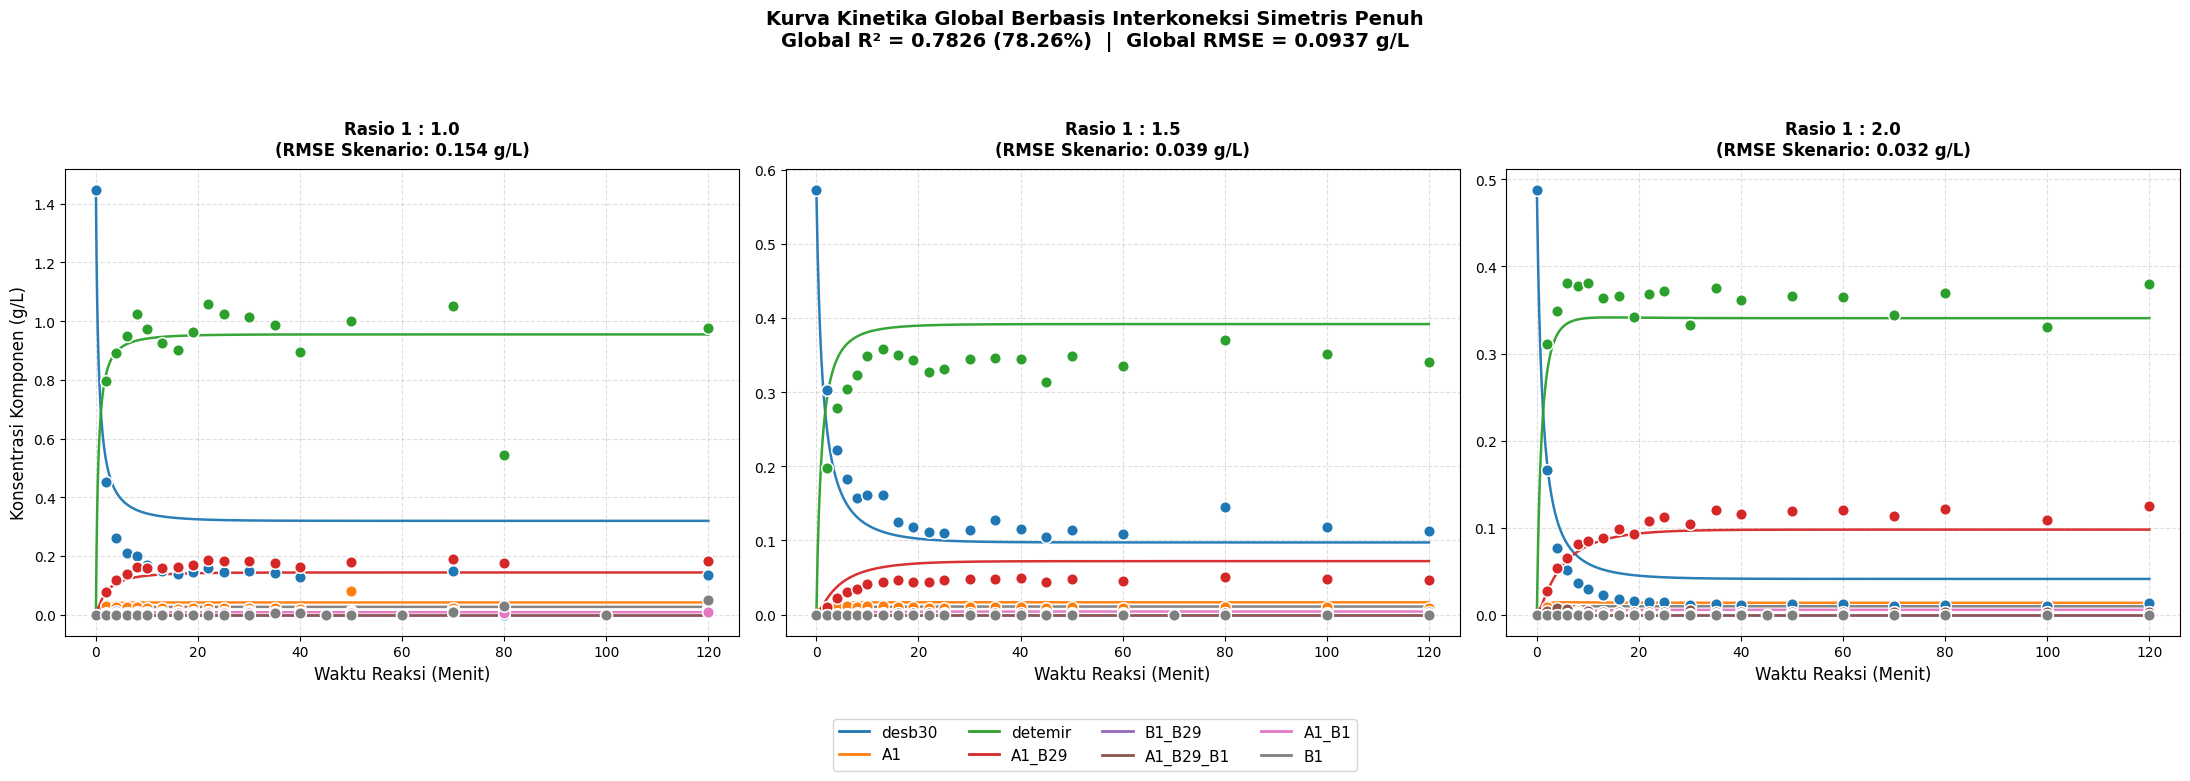


==================== RINGKASAN PERFORMA MODEL FINAL ====================
 >> Akurasi Tren Akhir (Global R²) : 0.7826 (78.26%)
 >> Deviasi Rata-rata (Global RMSE) : 0.0937 g/L


In [6]:
# ==============================================================================
# CELL 5: VALIDASI GRAFIK & DIAGNOSTIK
# ==============================================================================
y_true_global, y_pred_global = [], []

plot_colors = {
    'desb30': '#1f77b4', 'A1': '#ff7f0e', 'detemir': '#2ca02c', 
    'A1_B29': '#d62728', 'B1_B29': '#9467bd', 'A1_B29_B1': '#8c564b', 
    'A1_B1': '#e377c2', 'B1': '#7f7f7f'
}

time_smooth = np.linspace(time_exp[0], time_exp[-1], 1000)
fig, axes = plt.subplots(1, 3, figsize=(22, 6.5), sharey=False) 

print("=== ANALISIS ERROR PER SPESIES & RASIO ===")
mapping_idx = {'desb30': 1, 'A1': 2, 'B1': 3, 'detemir': 4, 'A1_B1': 5, 'A1_B29': 6, 'B1_B29': 7, 'A1_B29_B1': 8}

for idx, r in enumerate(ratios):
    y0 = np.zeros(9)
    y0[0] = (desb30_awal_gL[r] / MW['desb30']) * r
    
    for i, sp in enumerate(['desb30', 'A1', 'B1', 'detemir', 'A1_B1', 'A1_B29', 'B1_B29', 'A1_B29_B1']):
        y0[i+1] = experimental_dataset[r][sp][0] if len(experimental_dataset[r][sp]) > 0 else 0
        
    model = FinalKineticModel(final_params)
    sol_smooth = model.simulate(y0, (time_exp[0], time_exp[-1]), time_smooth)
    sol_exp = model.simulate(y0, (time_exp[0], time_exp[-1]), time_exp)
    
    y_true_ratio, y_pred_ratio = [], []
    
    print(f"\n--- Detil Presisi Rasio 1 : {r} ---")
    for sp in species_list:
        ode_pos = mapping_idx[sp]
        sim_gL_smooth = sol_smooth.y[ode_pos] * MW[sp]
        sim_gL_exp = sol_exp.y[ode_pos] * MW[sp]
        exp_gL = experimental_dataset[r][sp] * MW[sp]
        
        r2_sp = r2_score(exp_gL, sim_gL_exp) if np.std(exp_gL) > 1e-6 else np.nan
        if not np.isnan(r2_sp):
            print(f" -> R² {sp.upper():<10}: {r2_sp*100:.2f}%")
        else:
            print(f" -> R² {sp.upper():<10}: [Data Datar]")
            
        y_true_ratio.extend(exp_gL)
        y_pred_ratio.extend(sim_gL_exp)
        y_true_global.extend(exp_gL)
        y_pred_global.extend(sim_gL_exp)
        
        axes[idx].plot(time_smooth, sim_gL_smooth, color=plot_colors[sp], linewidth=1.8, alpha=0.95)
        axes[idx].scatter(time_exp, exp_gL, color=plot_colors[sp], edgecolors='white', linewidth=1.1, s=70, zorder=5)

    rmse_ratio = np.sqrt(mean_squared_error(y_true_ratio, y_pred_ratio))
    ax = axes[idx]
    ax.set_title(f"Rasio 1 : {r:.1f}\n(RMSE Skenario: {rmse_ratio:.3f} g/L)", fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel("Waktu Reaksi (Menit)", fontsize=12)
    if idx == 0:
        ax.set_ylabel("Konsentrasi Komponen (g/L)", fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.4)

global_r2 = r2_score(y_true_global, y_pred_global)
global_rmse = np.sqrt(mean_squared_error(y_true_global, y_pred_global))

dummy_handles = [plt.Line2D([0], [0], color=plot_colors[sp], lw=2) for sp in species_list]
fig.legend(dummy_handles, species_list, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=4, fontsize=11, frameon=True)

plt.suptitle(f"Kurva Kinetika Global Berbasis Interkoneksi Simetris Penuh\nGlobal R² = {global_r2:.4f} ({global_r2*100:.2f}%)  |  Global RMSE = {global_rmse:.4f} g/L", 
             fontsize=14, fontweight='bold', y=1.06)

plt.tight_layout()
plt.show()

print("\n==================== RINGKASAN PERFORMA MODEL FINAL ====================")
print(f" >> Akurasi Tren Akhir (Global R²) : {global_r2:.4f} ({global_r2*100:.2f}%)")
print(f" >> Deviasi Rata-rata (Global RMSE) : {global_rmse:.4f} g/L")
print("========================================================================")

INFO: File terbaca sebagai dictionary dengan keys: ['model_instance', 'parameters', 'final_sse', 'description', 'date']
INFO: Objek model ditemukan pada key: 'model_instance'

=== ANALISIS ERROR PER SKENARIO RASIO ===
Rasio 1 : 1.0 -> RMSE = 0.1733 g/L
Rasio 1 : 1.5 -> RMSE = 0.0641 g/L
Rasio 1 : 2.0 -> RMSE = 0.0577 g/L


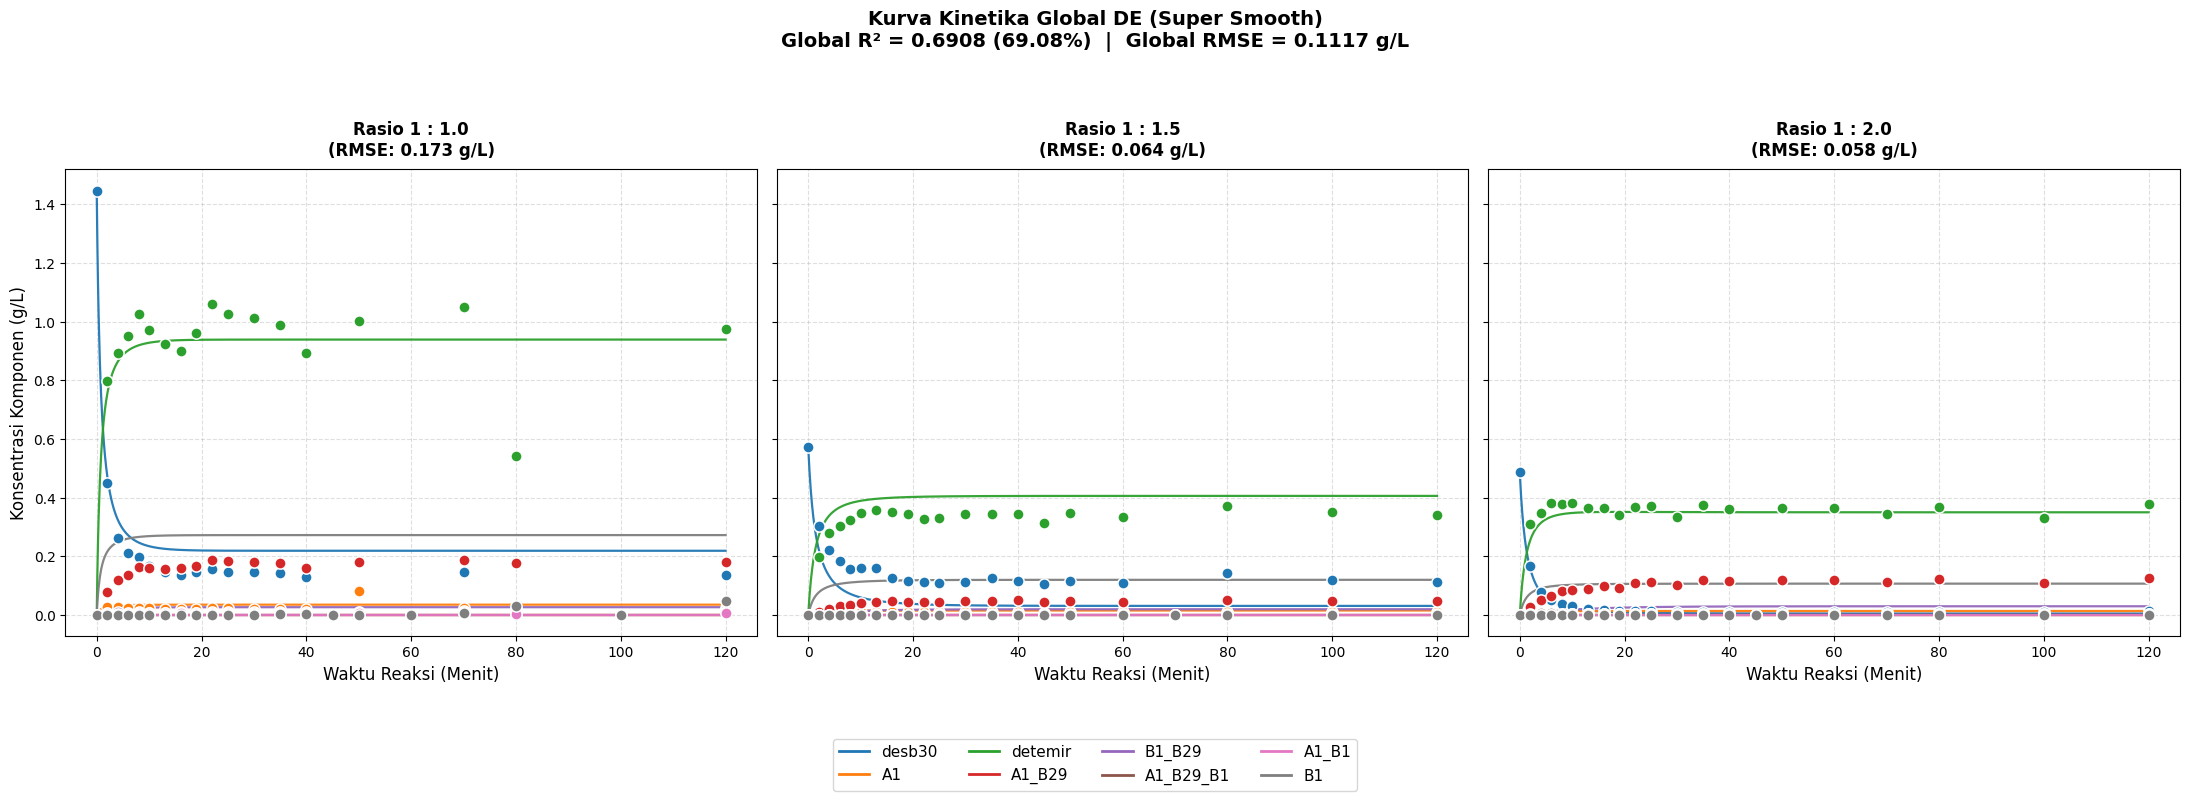


==================== RINGKASAN PERFORMA MODEL ====================
 >> Akurasi Tren (Global R²) : 0.6908 (69.08%)
 >> Deviasi Rata-rata (Global RMSE) : 0.1117 g/L


In [7]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import dill

# ==============================================================================
# 1. LOAD & UNBOXING MODEL SECARA AMAN DARI FILE .DILL
# ==============================================================================
with open('30jul2026_hydrolysis_kinetic_model.dill', 'rb') as f:
    checkpoint = dill.load(f)

# Unboxing otomatis jika model dibungkus dalam dictionary
if isinstance(checkpoint, dict):
    print("INFO: File terbaca sebagai dictionary dengan keys:", list(checkpoint.keys()))
    if 'model' in checkpoint:
        model_loaded = checkpoint['model']
    elif 'model_loaded' in checkpoint:
        model_loaded = checkpoint['model_loaded']
    else:
        # Mencari objek di dalam dict yang memiliki method 'simulate'
        model_loaded = None
        for key, val in checkpoint.items():
            if hasattr(val, 'simulate'):
                print(f"INFO: Objek model ditemukan pada key: '{key}'")
                model_loaded = val
                break
        if model_loaded is None:
            raise AttributeError("Gagal mengekstrak objek model dari dictionary. Pastikan objek model memiliki method '.simulate'.")
else:
    model_loaded = checkpoint

# ==============================================================================
# 2. PROSES VISUALISASI GRAFIK & ANALISIS ERROR
# ==============================================================================
y_true_global, y_pred_global = [], []

plot_colors = {
    'desb30': '#1f77b4', 'A1': '#ff7f0e', 'detemir': '#2ca02c', 
    'A1_B29': '#d62728', 'B1_B29': '#9467bd', 'A1_B29_B1': '#8c564b', 
    'A1_B1': '#e377c2', 'B1': '#7f7f7f'
}

time_smooth = np.linspace(0, 120, 1000)
fig, axes = plt.subplots(1, 3, figsize=(22, 6.5), sharey=True)

print("\n=== ANALISIS ERROR PER SKENARIO RASIO ===")

for idx, r in enumerate(ratios):
    # DYNAMIC Y0: Menyelaraskan dengan logika fungsi objektif Anda
    desb30_t0_molL = experimental_dataset[r]['desb30'][0]
    
    # Ambil index dan ukuran spesies secara dinamis dari model yang di-load
    y0 = np.zeros(len(model_loaded.species))
    y0[model_loaded.idx['nhs_myr']] = desb30_t0_molL * r
    y0[model_loaded.idx['desb30']] = desb30_t0_molL
        
    # Jalankan simulasi menggunakan model dari file .dill
    sol_smooth = model_loaded.simulate(y0, (0, 120), time_smooth)
    sol_exp = model_loaded.simulate(y0, (0, 120), time_exp)
    
    # Penampung lokal untuk RMSE per rasio
    r_true, r_pred = [], []
    
    for sp in species_list:
        ode_pos = model_loaded.idx[sp]
        
        sim_gL_smooth = sol_smooth.y[ode_pos] * MW[sp]
        sim_gL_exp = sol_exp.y[ode_pos] * MW[sp]
        exp_gL = experimental_dataset[r][sp] * MW[sp]
        
        # --- FIX INDEX ERROR MASKING ---
        # Mengatasi inkonsistensi jumlah titik dari solver ODE dengan interpolasi linear ke time_exp
        if len(sim_gL_exp) != len(exp_gL):
            sim_gL_exp_fixed = np.interp(time_exp, time_smooth, sim_gL_smooth)
        else:
            sim_gL_exp_fixed = sim_gL_exp
            
        # Masking NaNs pada data eksperimen (hanya menguji data riil)
        mask = ~np.isnan(exp_gL)
        valid_exp = exp_gL[mask]
        valid_sim = sim_gL_exp_fixed[mask]
        
        r_true.extend(valid_exp)
        r_pred.extend(valid_sim)
        
        # Tambahkan ke global tracker
        y_true_global.extend(valid_exp)
        y_pred_global.extend(valid_sim)
        
        # Plotting hasil simulasi kurva mulus vs data eksperimen berupa titik scatter
        axes[idx].plot(time_smooth, sim_gL_smooth, color=plot_colors[sp], linewidth=1.6, alpha=0.95)
        axes[idx].scatter(time_exp, exp_gL, color=plot_colors[sp], edgecolors='white', linewidth=1.1, s=65, zorder=5)

    rmse_ratio = np.sqrt(mean_squared_error(r_true, r_pred))
    print(f"Rasio 1 : {r:.1f} -> RMSE = {rmse_ratio:.4f} g/L")
    
    ax = axes[idx]
    ax.set_title(f"Rasio 1 : {r:.1f}\n(RMSE: {rmse_ratio:.3f} g/L)", fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel("Waktu Reaksi (Menit)", fontsize=12)
    if idx == 0:
        ax.set_ylabel("Konsentrasi Komponen (g/L)", fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.4)

# Hitung Statistik Global Akhir
global_r2 = r2_score(y_true_global, y_pred_global)
global_rmse = np.sqrt(mean_squared_error(y_true_global, y_pred_global))

# Penataan Legend & Title
dummy_handles = [plt.Line2D([0], [0], color=plot_colors[sp], lw=2) for sp in species_list]
fig.legend(dummy_handles, species_list, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=4, fontsize=11, frameon=True)

plt.suptitle(f"Kurva Kinetika Global DE (Super Smooth)\nGlobal R² = {global_r2:.4f} ({global_r2*100:.2f}%)  |  Global RMSE = {global_rmse:.4f} g/L", 
             fontsize=14, fontweight='bold', y=1.06)

plt.tight_layout()
plt.show()

print("\n==================== RINGKASAN PERFORMA MODEL ====================")
print(f" >> Akurasi Tren (Global R²) : {global_r2:.4f} ({global_r2*100:.2f}%)")
print(f" >> Deviasi Rata-rata (Global RMSE) : {global_rmse:.4f} g/L")
print("==================================================================")

In [ ]:
import numpy as np
from scipy.optimize import differential_evolution, minimize

print("Memulai Perhitungan Q2 (Cross-Validation)...")
print("Proses ini akan menyembunyikan titik data secara bergantian untuk menguji kemampuan prediksi model.")

# Ambil semua titik waktu unik dari eksperimen (kecuali menit ke-0)
unique_times = [t for t in time_exp if t > 0]

# Tempat menyimpan data riil dan data prediksi LOO (Leave-One-Out)
y_all_experimental = []
y_all_predicted = []

# Loop untuk menyembunyikan waktu satu per satu
for test_time in unique_times:
    print(f"\n[CV] Menyembunyikan data pada menit ke: {test_time}")
    
    # Fungsi objektif khusus yang mengabaikan waktu yang sedang diuji
    def objective_cv(log_params):
        k_vals = np.exp(log_params[:7])
        n, m = log_params[7], log_params[8]
        full_params = list(k_vals) + [n, m]
        
        total_sse = 0
        ratios = [1.0, 2.0]
        
        for r in ratios:
            y0 = np.zeros(9)
            desb30_molL = desb30_awal_gL[r] / MW['desb30']
            y0[0] = desb30_molL * r  
            
            for i, sp in enumerate(['desb30', 'A1', 'B1', 'detemir', 'A1_B1', 'A1_B29', 'B1_B29', 'A1_B29_B1']):
                y0[i+1] = experimental_dataset[r][sp][0] if len(experimental_dataset[r][sp]) > 0 else 0
                
            model = FinalKineticModel(full_params)
            sol = model.simulate(y0, (time_exp[0], time_exp[-1]), time_exp)
            
            if sol.status != 0 or np.isnan(sol.y).any() or np.isinf(sol.y).any(): 
                return 1e12
            
            mapping_idx = {
                'desb30': 1, 'A1': 2, 'B1': 3, 'detemir': 4, 
                'A1_B1': 5, 'A1_B29': 6, 'B1_B29': 7, 'A1_B29_B1': 8
            }
            
            for sp in species_list:
                ode_pos = mapping_idx[sp]
                sim_gL = sol.y[ode_pos] * MW[sp]
                exp_gL = experimental_dataset[r][sp] * MW[sp]
                
                # JALUR UTAMA: Hitung error HANYA untuk waktu yang tidak disembunyikan
                for t_idx, t_val in enumerate(time_exp):
                    if t_val == test_time:
                        continue # Abaikan waktu uji dari kalkulasi training
                    
                    max_val = np.max(exp_gL)
                    weight = 1.0 / (np.sqrt(max_val) + 1e-5) if max_val > 0 else 1.0
                    total_sse += weight * (sim_gL[t_idx] - exp_gL[t_idx])**2
                    
        return total_sse

    # Jalankan optimasi cepat untuk data training yang tersisa
    res_de_cv = differential_evolution(objective_cv, bounds, popsize=10, maxiter=20, seed=42, workers=1)
    res_local_cv = minimize(objective_cv, res_de_cv.x, method='L-BFGS-B', bounds=bounds, options={'maxiter': 300})
    
    # Gunakan parameter hasil training untuk MEMPREDIKSI titik yang disembunyikan
    best_params_cv = list(np.exp(res_local_cv.x[:7])) + [res_local_cv.x[7], res_local_cv.x[8]]
    model_trained = FinalKineticModel(best_params_cv)
    
    # Ambil nilai prediksi vs eksperimen pada menit 'test_time' tersebut
    t_test_idx = np.where(time_exp == test_time)[0][0]
    ratios = [1.0, 2.0]
    mapping_idx = {
        'desb30': 1, 'A1': 2, 'B1': 3, 'detemir': 4, 
        'A1_B1': 5, 'A1_B29': 6, 'B1_B29': 7, 'A1_B29_B1': 8
    }
    
    for r in ratios:
        y0 = np.zeros(9)
        desb30_molL = desb30_awal_gL[r] / MW['desb30']
        y0[0] = desb30_molL * r  
        for i, sp in enumerate(['desb30', 'A1', 'B1', 'detemir', 'A1_B1', 'A1_B29', 'B1_B29', 'A1_B29_B1']):
            y0[i+1] = experimental_dataset[r][sp][0] if len(experimental_dataset[r][sp]) > 0 else 0
            
        sol_trained = model_trained.simulate(y0, (time_exp[0], time_exp[-1]), time_exp)
        
        for sp in species_list:
            ode_pos = mapping_idx[sp]
            pred_val = sol_trained.y[ode_pos][t_test_idx] * MW[sp]
            exp_val = experimental_dataset[r][sp][t_test_idx] * MW[sp]
            
            y_all_experimental.append(exp_val)
            y_all_predicted.append(pred_val)

# KONTROL AKHIR: Menghitung nilai Q^2 secara statistik global
y_all_experimental = np.array(y_all_experimental)
y_all_predicted = np.array(y_all_predicted)

press = np.sum((y_all_experimental - y_all_predicted) ** 2)
tss = np.sum((y_all_experimental - np.mean(y_all_experimental)) ** 2)
q_square = 1 - (press / tss)

print("\n" + "=" * 40)
print(f"HASIL AKHIR VALIDASI MODEL KINETIKA:")
print(f" -> Statistik Q2 (Predictability): {q_square * 100:.2f}%")
print("=" * 40)

Memulai Perhitungan Q2 (Cross-Validation)...
Proses ini akan menyembunyikan titik data secara bergantian untuk menguji kemampuan prediksi model.

[CV] Menyembunyikan data pada menit ke: 2

[CV] Menyembunyikan data pada menit ke: 4

[CV] Menyembunyikan data pada menit ke: 6

[CV] Menyembunyikan data pada menit ke: 8

[CV] Menyembunyikan data pada menit ke: 10

[CV] Menyembunyikan data pada menit ke: 13

[CV] Menyembunyikan data pada menit ke: 16

[CV] Menyembunyikan data pada menit ke: 19

[CV] Menyembunyikan data pada menit ke: 22

[CV] Menyembunyikan data pada menit ke: 25
